# Dark Matter Data Handling with Gammapy

In any dark matter indirect detection analysis, the first step is to define
what data you are going to work with. Gammapy supports two complementary 
approaches:

- **Simulated data:** you generate synthetic observations from a theoretical 
  model.

- **Real data:** you load actual telescope observations in DL3 format and 
  reduce them to a dataset ready for statistical analysis.

In both cases, the analysis is identical in Gammapy. This means that a pipeline developed on simulations can be directly applied to real data with minimal changes.

## Simulating Dark Matter Observations

To simulate an observation we need three ingredients:

- **A signal model:** the expected gamma-ray spectrum from DM annihilation 
  or decay, built from the J/D-factor and the particle physics spectrum 
  (see Tutorial **XXXXX**).
- **A background model:** the residual cosmic-ray background surviving 
  the gamma/hadron separation cuts.
- **Instrument Response Functions (IRFs):** the telescope's effective area, 
  energy dispersion, and PSF, which translate the physical flux into 
  observable counts.

We will simulate observations of the **Draco dwarf spheroidal galaxy** using CTA-North IRFs (prod5 configuration). Also, we will use for the example the case of an annihilation with the channel b.

Additionally, we will describe below the two simulation strategies are available in Gammapy: Asimov and Monte Carlo.

In the next steps we are going to cover all the necessary components and the final simulation with both approaches.



### Setup

In [ ]:
from gammapy.data import Observation
from gammapy.datasets import MapDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import (
    MapDatasetMaker,
    SafeMaskMaker
)
from gammapy.maps import MapAxis, WcsGeom, WcsNDMap
from gammapy.modeling.models import (
    FoVBackgroundModel,
    Models,
    SkyModel,
    PointSpatialModel
)
from gammapy.astro.darkmatter import (
    DarkMatterAnnihilationSpectralModel
)
from gammapy.astro.darkmatter.profiles import EinastoProfile

import astropy.units as u
from astropy.coordinates import SkyCoord, EarthLocation, AltAz
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt



### Target source

We define our target source. For a realistic simulation, we need to know the object's elevation in the sky from the telescope's location at the specific observation time we want to simulate. This affects which IRF (zenith angle dependent) we should use.

In [ ]:
# Source coordinates
draco_pos = SkyCoord(ra=260.05167 * u.deg, dec=57.915 * u.deg, frame="icrs")
draco_dist = 76 * u.kpc

# Location coordinates, i.e CTA-North
cta_norte = EarthLocation(lat=28.762 * u.deg, lon=-17.89 * u.deg, height=2200 * u.m)  

# Observation start time
obs_time = Time("2025-06-17 01:00:00")  # UTC

altaz = AltAz(obstime=obs_time, location=cta_norte)
draco_altaz = draco_pos.transform_to(altaz)

# Altitude and zenith angle
altitude = draco_altaz.alt.deg
zenith_angle = 90 - altitude

print(f"Altitude: {altitude:.2f}°")
print(f"Zenith angle: {zenith_angle:.2f}°")

### Signal model
We define the particle physics properties: the annihilation/decay channel (e.g., h bosons), the particle mass, and the J/D-Factor (the line-of-sight integral of the DM density squared).

In [ ]:
# DM parameters: mass and channel
channel = "b"
massDM = 10 * u.TeV

# Density profile
rho_s_msun_kpc3 = 1.3e7 * (u.M_sun / u.kpc**3)  

# From M_sun/kpc³ to GeV/cm³
rho_s_GeV_cm3 = rho_s_msun_kpc3.to(u.GeV / u.cm**3, equivalencies=u.mass_energy())

# Jfactor - This can also be calculated with the class JFactory
jfact_draco = 1.66e23 * u.GeV**2 / u.cm**5 

draco_profile = EinastoProfile(
    r_s=0.91 * u.kpc,       
    rho_s=rho_s_GeV_cm3
)

### Map geometry and energy range
We define the energy range for the simulation and the spatial resolution of our World Coordinate System (WCS) map.

In [ ]:
# Set energy bounds
energy_edges = np.logspace(-1, 2, 15) 
energy_reco = MapAxis.from_edges(energy_edges, unit="TeV", name="energy", interp="log")
energy_true = MapAxis.from_edges(energy_edges, unit="TeV", name="energy_true", interp="log")

# Geometry map
geom_draco = WcsGeom.create(
    skydir=draco_pos,
    binsz=0.01,
    width=5.0, # Width of our simulation geometry
    frame="icrs",
    axes=[energy_reco]  
)

### Sky model
We combine the spatial model (treating Draco as a point source) with the DM annihilation spectral model. 

The Spatial Model defines the shape and position of our target. We use a PointSpatialModel centered on Draco. While DM halos are technically extended, Draco is compact enough that a point-source approximation is a standard starting point relative to the telescope's resolution.

The Spectral Model defines the gamma-ray flux as a function of energy. We use the DarkMatterAnnihilationSpectralModel, which combines Particle Physics (mass and annihilation channel) with Astrophysics (the J-Factor).

In [ ]:
# Spatial model
spatial_model = PointSpatialModel(
    lon_0=draco_pos.ra,
    lat_0=draco_pos.dec,
    frame="icrs"
)

# Spectral model
spectral_model = DarkMatterAnnihilationSpectralModel(
    mass=massDM, channel=channel, jfactor=jfact_draco)

# Combined model
model_simu = SkyModel(
    spatial_model=spatial_model,
    spectral_model=spectral_model,
    name="draco-dm"
)

### IRF and observation setup
We load the IRFs (Instrument Response Functions), which represent the "fingerprint" of the telescope. They describe how the instrument distorts the signal: Effective Area (efficiency), PSF (spatial blurring), and Energy Dispersion (energy resolution). In this simulation, they translate our theoretical Dark Matter flux into the realistic "counts" the CTA would actually detect. 
The IRFs depend on the telescope's zenith angle at the time of observation, 
since higher zenith angles increase the effective energy threshold and reduce 
the collection area at low energies. We computed above that Draco transits at 
a zenith angle of ~29° as seen from CTA-North. We therefore load the `z20` 
IRF set (20° zenith), which is the closest available configuration in the 
CTA prod5 release and a standard choice for sources with zenith angles 
below ~35°.

In [ ]:
# Load CTA Prod5 IRFs
irf_path = r"/Users/alexcervino/Desktop/DARKMATTER/ksp_dsph_material/IRFs/cta/prod5-v0.1/bcf/North_z20_N_50h/Prod5-North-20deg-NorthAz-4LSTs09MSTs.180000s-v0.1.fits.gz"
irfs = load_irf_dict_from_file(irf_path)

# Create the Observation: 500 hours of livetime
livetime = 500 * u.h
obs = Observation.create(
    pointing=draco_pos, 
    livetime=livetime, 
    irfs=irfs, 
    reference_time=obs_time
)

### Simulation
In this final step, we apply the models and IRFs to generate a synthetic event count map. In this case we are going to simulate using the two approaches mentioned before, using Asimov and Monte Carlo.

In [ ]:
# 1. Create an empty MapDataset
empty = MapDataset.create(geom=geom_draco, name="dataset-simu-draco", energy_axis_true=energy_true)

# 2. Setup Maker to calculate exposure, background, PSF, and energy dispersion
maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])
maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=2.5 * u.deg)

# 3. Run the maker and attach models
dataset = maker.run(empty, obs)
dataset = maker_safe_mask.run(dataset, obs)

# Attach the DM model and a Field-of-View background model
bkg_model = FoVBackgroundModel(dataset_name="dataset-simu-draco")
dataset.models = Models([model_simu, bkg_model])

### Asimov dataset
The Asimov dataset is a mathematically convenient dataset where the counts are set equal exactly to the model prediction, with no statistical noise. This concept (Cowan et al. 2011) is widely used in HEP and gamma-ray astronomy because a single Asimov dataset directly yields the *median expected* sensitivity, without needing to average over hundreds of MC realizations.

 It corresponds to the "median experiment" — what you would observe on average over many 
realizations. It is the standard approach for computing **expected upper 
limits** and **sensitivity curves**, and is much faster than running 
many Monte Carlo realizations.

In [ ]:
# Copy the base dataset (models already attached, counts not yet filled)
dataset_asimov = dataset.copy(name="dataset-asimov-draco")

# Set counts equal to the model prediction — no Poisson sampling
dataset_asimov.counts = dataset_asimov.npred()

print("=== Asimov Dataset ===")
print(f"Predicted counts : {dataset_asimov.npred().data.sum():.2f}")
print(f"Asimov counts    : {dataset_asimov.counts.data.sum():.2f}")


### Monte Carlo dataset
A Monte Carlo (MC) dataset is generated by drawing Poisson random numbers 
around the expected counts. Each realization represents one possible 
outcome of the actual observation. Running many MC realizations allows 
you to **validate** the statistical coverage of your analysis and to 
cross-check the sensitivity bands derived from the Asimov approach.

In [ ]:
# Copy the base dataset
dataset_mc = dataset.copy(name="dataset-mc-draco")

# Sample Poisson fluctuations around the prediction
# random_state fixes the seed for reproducibility
dataset_mc.fake(random_state=42)

print("=== MC Observation ===")
print(f"Predicted counts : {dataset_mc.npred().data.sum():.2f}")
print(f"Simulated counts : {dataset_mc.counts.data.sum()}")

## Simulation inspection

Before proceeding to the statistical analysis, it is good practice to visually 
inspect the simulated datasets. This allows us to verify that the simulation 
is physically reasonable and that the signal is visible above the background.

We show three visualizations:

- **Interactive count map:** allows you to browse the spatial distribution 
  of counts slice by slice in energy, which is useful for identifying 
  where the signal contributes most.
- **Integrated count map:** the counts summed over all energy bins, giving 
  a global view of the spatial morphology.
- **Energy-restricted count map:** counts integrated over a narrow energy 
  window around the signal peak, where the DM signal-to-background ratio 
  is highest.

In all cases we compare the Asimov and MC datasets side by side. The Asimov 
map is smooth by construction, while the MC map shows the pixel-to-pixel 
Poisson fluctuations expected in a real observation.

In [ ]:
# ─────────────────────────────────────────────
# Interactive comparison: Asimov vs MC
# ─────────────────────────────────────────────
print("=== Asimov ===")
dataset_asimov.counts.smooth(0.05 * u.deg).plot_interactive(add_cbar=True, stretch="linear")
plt.show()

print("=== MC ===")
dataset_mc.counts.smooth(0.05 * u.deg).plot_interactive(add_cbar=True, stretch="linear")
plt.show()

# ─────────────────────────────────────────────
# Static comparison: summed over all energies
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

dataset_asimov.counts.reduce_over_axes().smooth(0.05 * u.deg).plot(
    ax=axes[0], add_cbar=True
)
axes[0].set_title("Asimov (no fluctuations)")

dataset_mc.counts.reduce_over_axes().smooth(0.05 * u.deg).plot(
    ax=axes[1], add_cbar=True
)
axes[1].set_title("MC Observation (seed=42)")

plt.suptitle(f"Count maps — DM annihilation ({channel} channel, {massDM})")
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# Static comparison: restricted energy range
# ─────────────────────────────────────────────
energy_min = 3.16 * u.TeV
energy_max = 5.18 * u.TeV
energy_axis = dataset_asimov.counts.geom.axes["energy"]
energy_indices = np.where(
    (energy_axis.center >= energy_min) & (energy_axis.center <= energy_max)
)[0]

geom_image = dataset_asimov.counts.geom.to_image()

for ds, label in [(dataset_asimov, "Asimov"), (dataset_mc, "MC Observation")]:
    counts_sum = ds.counts.data[energy_indices, :, :].sum(axis=0)
    counts_map = WcsNDMap(geom=geom_image, data=counts_sum)
    smoothed_map = counts_map.smooth(0.05 * u.deg)

    fig, ax = plt.subplots()
    smoothed_map.plot(ax=ax, add_cbar=True)
    ax.set_title(f"{label} — {energy_min:.2f} to {energy_max:.2f}")
    plt.show()

#### Dataset summary

The `peek()` method provides a quick overview of the dataset in a single figure. 
It shows the integrated count map, the predicted counts from the model, 
the residuals (data minus prediction), and the energy spectrum summed over 
the spatial axes. 

When inspecting this plot, check that:
- The residual map is consistent with noise (no obvious spatial structure).
- The spectral shape of the counts matches the expected DM annihilation 
  spectrum: rising steeply below the DM mass cutoff and dropping sharply above it.
- The predicted counts (npred) and the Asimov counts are identical, 
  confirming that the dataset was set up correctly.

/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encou

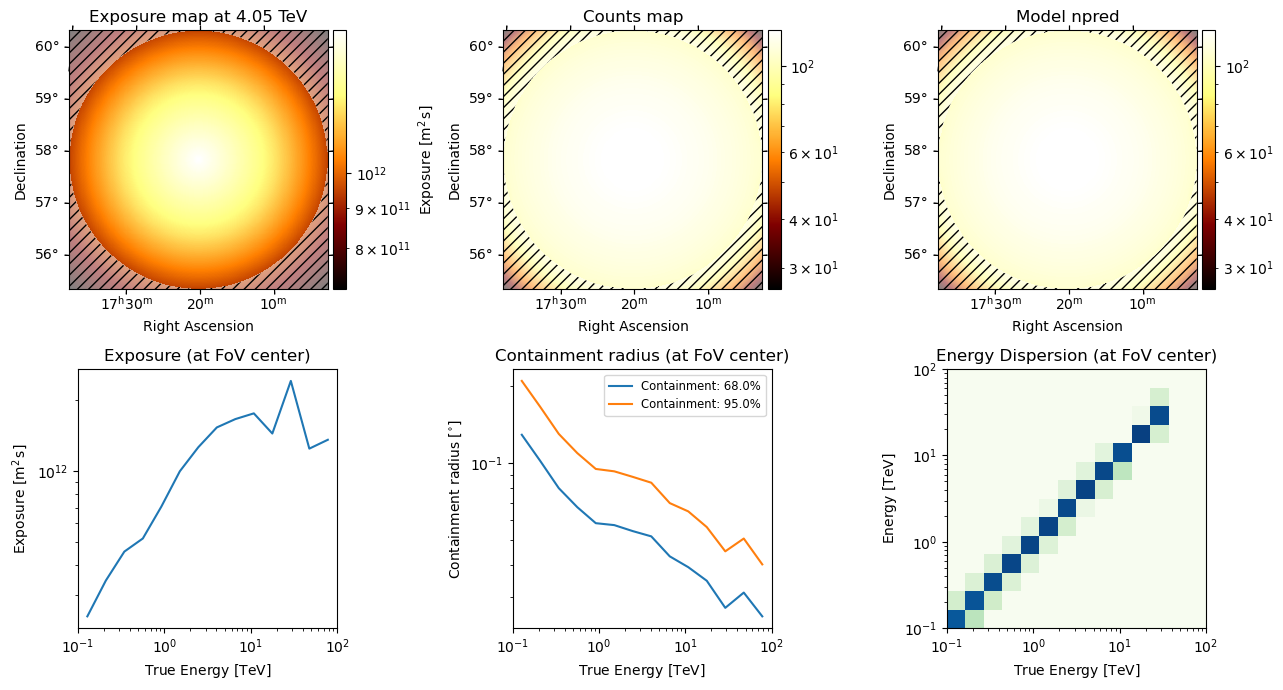

In [20]:
dataset_asimov.peek()

## Real Data Reduction

When working with real telescope observations, the data arrive in **DL3 format**: 
event lists and IRFs stored as FITS files, one per observation run. Instead of 
generating synthetic counts from a model, we load and reduce these files into 
the same `MapDataset` structure used in the simulation above.

We use the **H.E.S.S. DL3 DR1** public dataset included in `gammapy-data` as 
an example. Although it covers the Crab Nebula rather than a dSph, the 
reduction pipeline is identical — only the target coordinates and IRF choice 
would change for a real dSph analysis.

The reduction follows three steps:
1. **Load the data store** from the DL3 directory.
2. **Select observations** by target position.
3. **Run the makers** to bin the events into a `MapDataset`.

### Loading the data store

A `DataStore` points to a directory containing DL3 files organized according 
to the GADF (Gamma-ray Astronomy Data Format) convention. From it we can 
select observations by source position or observation ID.

In [25]:
from gammapy.data import DataStore

# Load the H.E.S.S. DL3 DR1 data store (included in gammapy-data)
data_store = DataStore.from_dir("$GAMMAPY_DATA/hess-dl3-dr1/")
print(data_store.obs_table[["OBS_ID", "RA_PNT", "DEC_PNT", "LIVETIME"]])

OBS_ID   RA_PNT   DEC_PNT    LIVETIME
          deg       deg         s    
------ --------- ---------- ---------
 20136  228.6125 -58.771667 1521.0269
 20137  228.6125 -59.771667  819.2054
 20151  228.6125 -58.771667  1530.479
 20275 187.27792   2.552389 1525.8447
 20282  228.6125 -58.771667 1543.3231
 20283  228.6125 -59.771667 1547.8253
 20301  228.6125 -58.771667 1534.0626
 20302  228.6125 -59.771667 1535.3478
 20303  228.6125 -58.771667 1535.1606
   ...       ...        ...       ...
 33798 329.71667 -30.725555 1572.3356
 33799 329.71667 -29.725555 1580.9498
 33800 329.13797 -30.225555 1591.7136
 33801 330.29538 -30.225555 1598.6652
 47802 330.29538 -30.225555 1572.4065
 47803 329.13797 -30.225555 1566.9369
 47804 329.71667 -29.725555 1560.2717
 47827 330.29538 -30.225555 1575.5515
 47828 329.13797 -30.225555 1562.4288
 47829 329.71667 -30.725555 1559.6072
Length = 105 rows


### Observation selection

We select the observations pointing towards the Crab Nebula. In a real dSph 
analysis you would replace `crab_pos` with your target coordinates.

In [26]:
from astropy.coordinates import SkyCoord
import astropy.units as u

crab_pos = SkyCoord(ra=83.633 * u.deg, dec=22.014 * u.deg, frame="icrs")

# Select observations within 2.5° of the Crab
selected_obs = data_store.get_observations(
    data_store.obs_table.select_sky_circle(
        center=crab_pos, radius=2.5 * u.deg
    )["OBS_ID"]
)

print(f"Number of selected observations: {len(selected_obs)}")

Number of selected observations: 4


### Dataset reduction

We reuse the same `MapDatasetMaker` and `SafeMaskMaker` as in the simulation. 
The only difference is that instead of a single synthetic `Observation`, 
we loop over the real runs and stack them into a single dataset.

MapDataset
----------

  Name                            : dataset-real-crab 

  Total counts                    : 0 
  Total background counts         : 8475.15
  Total excess counts             : -8475.15

  Predicted counts                : 8475.15
  Predicted background counts     : 8475.15
  Predicted excess counts         : nan

  Exposure min                    : 2.26e+06 m2 s
  Exposure max                    : 3.63e+09 m2 s

  Number of total bins            : 315000 
  Number of fit bins              : 292500 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : nan

  Number of models                : 0 
  Number of parameters            : 0
  Number of free parameters       : 0




/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encountered in do_format (vectorized)
  outputs = ufunc(*inputs)
/Users/alexcervino/anaconda3/envs/darkmatter_env/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:2605: RuntimeWarning: invalid value encou

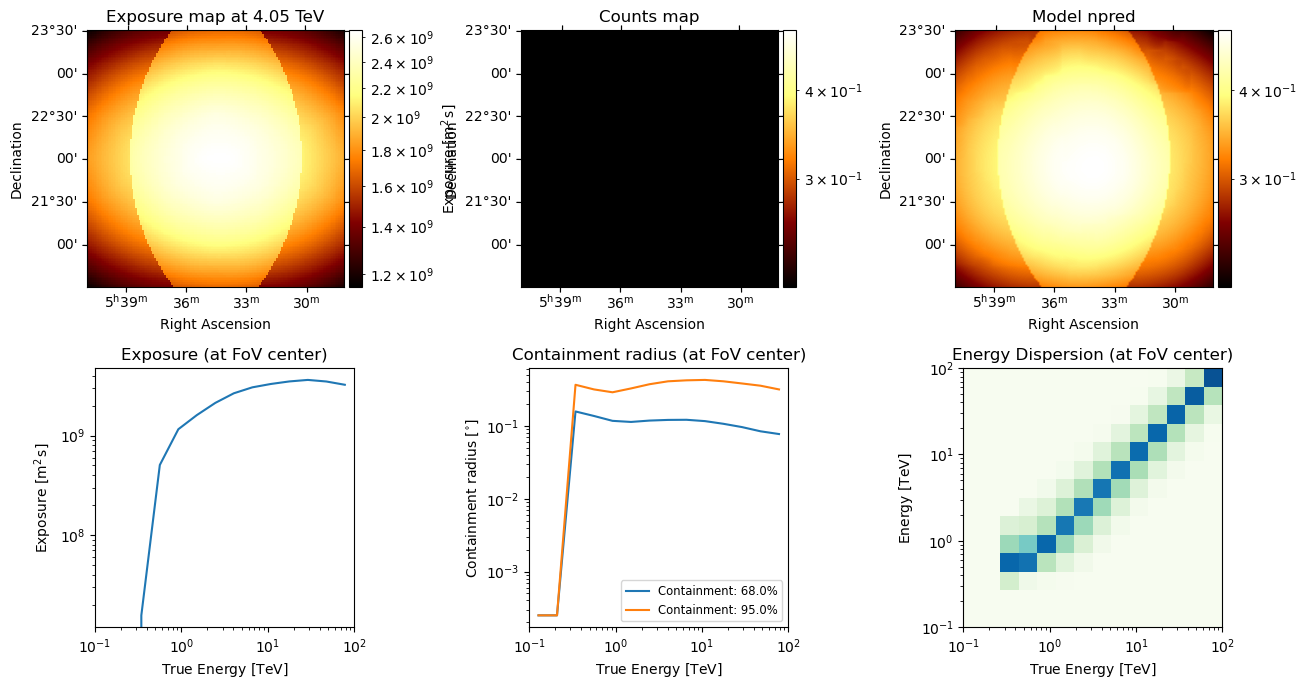

In [27]:
from gammapy.datasets import MapDataset
from gammapy.makers import MapDatasetMaker, SafeMaskMaker
from gammapy.maps import MapAxis, WcsGeom
import numpy as np

# Define geometry centered on the Crab
energy_edges = np.logspace(-1, 2, 15)
energy_reco = MapAxis.from_edges(energy_edges, unit="TeV", name="energy", interp="log")
energy_true = MapAxis.from_edges(energy_edges, unit="TeV", name="energy_true", interp="log")

geom_crab = WcsGeom.create(
    skydir=crab_pos,
    binsz=0.02,
    width=3.0,
    frame="icrs",
    axes=[energy_reco]
)

# Empty reference dataset
empty = MapDataset.create(
    geom=geom_crab,
    name="dataset-real-crab",
    energy_axis_true=energy_true
)

maker = MapDatasetMaker(selection=["exposure", "background", "psf", "edisp"])
maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=2.5 * u.deg)

# Stack all runs
stacked = empty.copy(name="dataset-real-crab")

for obs in selected_obs:
    dataset = maker.run(empty.copy(), obs)
    dataset = maker_safe_mask.run(dataset, obs)
    stacked.stack(dataset)

print(stacked)
stacked.peek()

### From real data to DM analysis

Once the dataset is stacked, the structure is identical to the simulated 
datasets produced earlier. You can attach the `DarkMatterAnnihilationSpectralModel` 
and a `FoVBackgroundModel` in exactly the same way, and proceed directly 
to likelihood fitting and upper limit computation.

In a real dSph analysis, the steps above would be repeated with:
- The target coordinates of your dSph (e.g. Draco).
- IRFs matched to the actual zenith angle of the observations.
- A quality selection on the runs based on atmospheric conditions or 
  data quality flags from the observation index table.

## References

- **Source position and distance of Draco:** McConnachie, A. W. 2012, *AJ*, 144, 4
  — The observed properties of dwarf galaxies in and around the Local Group.
  [arXiv:1204.1562](https://arxiv.org/abs/1204.1562)

- **DM density profile and J-factor (Draco):** Bonnivard, V. et al. 2015,
  *MNRAS*, 453, 849
  — Dark matter annihilation and decay in dwarf spheroidal galaxies: The classical and ultrafaint dSphs.
  [arXiv:1504.02048](https://arxiv.org/abs/1504.02048)

- **Asimov dataset:** Cowan, G. et al. 2011, *EPJC*, 71, 1554
  — Asymptotic formulae for likelihood-based tests of new physics.
  [arXiv:1007.1727](https://arxiv.org/abs/1007.1727)